# Reproducing their results
This file just serves as an initial step to verify we can reproduce their power law findings on variance and PC dimension, and their decoding accuracy based on neural responses (the other files decode with PCs).

Most of this code is based on Stringer's powerlaws.ipynb file. We just wanted to reproduce the figures in this file for our 7 datasets. 

## Preprocessing data
Here we load datasets from 7 recordings and define a function for extracting the data and performing PCA on the neural responses. 

Note: ~2800 images were shown in the same order for multiple trials. The number of trial repeats varies per dataset. 

In [ ]:
# Imports
from scipy import io
import os
import numpy as np
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from scipy.sparse.linalg import eigsh


# Load files
dat = io.loadmat('/Users/jessicalau/natimg2800_M170714_MP032_2017-09-14.mat')
dat2 = io.loadmat('/Users/jessicalau/natimg2800_M170717_MP034_2017-09-11.mat')
dat3 = io.loadmat('/Users/jessicalau/natimg2800_M170714_MP032_2017-08-07.mat')
dat4 = io.loadmat('/Users/jessicalau/natimg2800_M161025_MP030_2017-05-29.mat')
dat5 = io.loadmat('/Users/jessicalau/natimg2800_M170717_MP033_2017-08-20.mat')
dat6 = io.loadmat('/Users/jessicalau/natimg2800_M160825_MP027_2016-12-14.mat')
dat7 = io.loadmat('/Users/jessicalau/natimg2800_M170604_MP031_2017-06-28.mat')

# Preprocess data (these preprocessing steps were copied from their notebooks)
def preprocess(dat):
    resp  = dat['stim'][0]['resp'][0]    # Neural responses: stim x neurons
    spont = dat['stim'][0]['spont'][0]   # Spontaneous activity: timepoints x neurons
    istim = dat['stim'][0]['istim'][0].astype(np.int32)[:, 0] - 1   # Stimulus IDs

    # -- Remove blank-stimulus trials -- 
    nimg = istim.max()              # this is index where blank images start
    resp  = resp[istim < nimg, :]   # remove blank stimuli from responses
    istim = istim[istim < nimg]     # remove blank stimuli from stimulus IDs

    # -- Z-score responses using spontaneous activity stats -- 
    mu = spont.mean(axis=0)         # per-neuron mean of spont. activity
    sd = spont.std(axis=0) + 1e-6   # per-neuron std of spont. activity
    resp  = (resp  - mu) / sd       
    spont = (spont - mu) / sd       


    # -- Regress out top 32 dimensions of spontaneous activity --
    # eigsh gives the top-k eigenvectors of the spontaneous covariance matrix;
    # these capture shared fluctuations (arousal, drift) unrelated to the stimulus.
    # Projecting them out of resp removes this noise source.
    sv, u = eigsh(spont.T @ spont, k=32)   # u: (n_neurons x 32)
    resp  = resp - (resp @ u) @ u.T         # subtract projection onto spontaneous subspace

    # -- Remove any residual per-neuron offset after z-scoring -- 
    resp -= resp.mean(axis=0)

    # -- Split trials into two independent repeats per stimulus -- 
    # sresp[0, n] and sresp[1, n] are the mean responses to image n from the first and second halves of its trials respectively
    NN    = resp.shape[1]
    sresp = np.zeros((2, nimg, NN), np.float64)
    inan  = np.zeros(nimg, dtype=bool)
    for n in range(nimg):
        ist = (istim == n).nonzero()[0]          # indices of all trials for image n
        i1, i2 = ist[:len(ist)//2], ist[len(ist)//2:]
        if len(i1) < 1 or len(i2) < 1:          # skip images with fewer than 2 trials
            inan[n] = True
        else:
            sresp[0, n] = resp[i1].mean(axis=0)  # repeat 0: average over first-half trials
            sresp[1, n] = resp[i2].mean(axis=0)  # repeat 1: average over second-half trials
    sresp = sresp[:, ~inan, :]                   # drop images that lacked two repeats

    return sresp

    # return sresp, scores0, scores1, n_pc, sresp.shape[1]


datasets  = [dat, dat2, dat3, dat4, dat5, dat6, dat7]
mouse_ids = ['MP032-Sep14', 'MP034-Sep11', 'MP032-Aug07',
             'MP030-May29', 'MP033-Aug20', 'MP027-Dec14', 'MP031-Jun28']

In [1]:

# cvPCA utility functions (copied from utils.py)

def cvPCA(X):
    ''' X is 2 x stimuli x neurons '''
    pca = PCA(n_components=min(1024, X.shape[1])).fit(X[0].T)
    u   = pca.components_.T
    sv  = pca.singular_values_
    xproj  = X[0].T @ (u / sv)
    cproj0 = X[0] @ xproj
    cproj1 = X[1] @ xproj
    return (cproj0 * cproj1).sum(axis=0)

def shuff_cvPCA(X, nshuff=5):
    ''' X is 2 x stimuli x neurons '''
    nc = min(1024, X.shape[1])
    ss = np.zeros((nshuff, nc))
    for k in range(nshuff):
        iflip = np.random.rand(X.shape[1]) > 0.5
        X0 = X.copy()
        X0[0, iflip] = X[1, iflip]
        X0[1, iflip] = X[0, iflip]
        ss[k] = cvPCA(X0)
    return ss

def get_powerlaw(ss, trange):
    ''' fit exponent to variance curve '''
    logss = np.log(np.abs(ss))
    y  = logss[trange][:, np.newaxis]
    trange += 1
    nt = trange.size
    x  = np.concatenate((-np.log(trange)[:, np.newaxis], np.ones((nt, 1))), axis=1)
    w  = 1.0 / trange.astype(np.float32)[:, np.newaxis]
    b  = np.linalg.solve(x.T @ (x * w), (w * x).T @ y).flatten()
    allrange = np.arange(0, ss.size).astype(int) + 1
    x  = np.concatenate((-np.log(allrange)[:, np.newaxis], np.ones((ss.size, 1))), axis=1)
    ypred = np.exp((x * b).sum(axis=1))
    return b[0], ypred


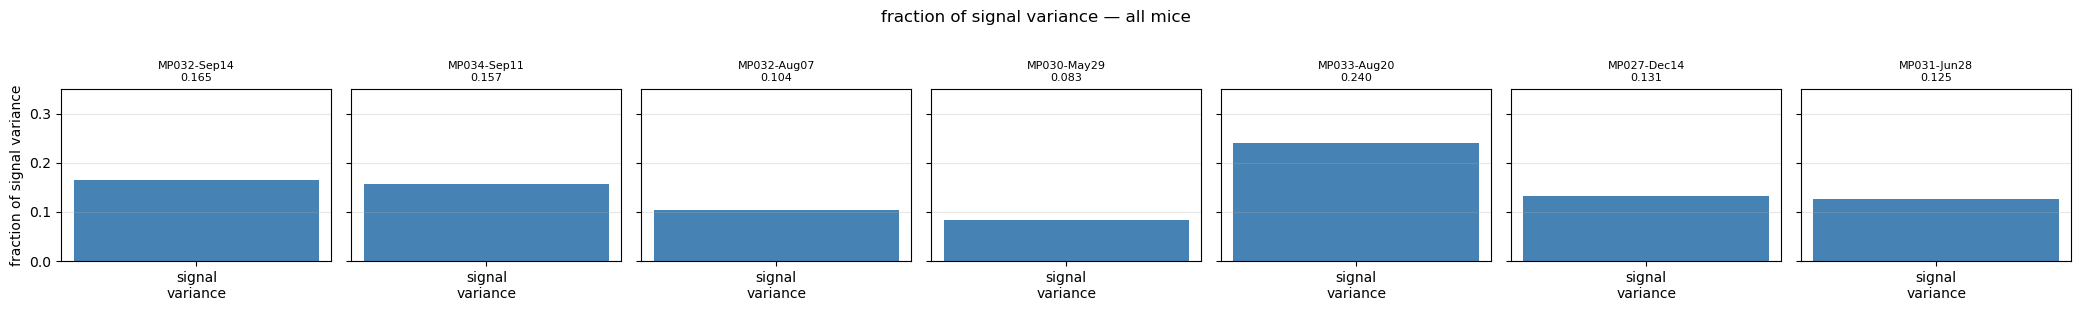

In [4]:

# Signal variance: fraction of each neuron's variance that is stimulus-driven
# Computed as the mean diagonal of the cross-correlation matrix between
# z-scored responses from repeat 0 and repeat 1.

fig, axes = plt.subplots(1, 7, figsize=(21, 3), sharey=True)

for ax, d, label in zip(axes, datasets, mouse_ids):
    sresp = preprocess(d)
    snorm = sresp - sresp.mean(axis=1)[:, np.newaxis, :]
    snorm = snorm / (snorm.std(axis=1)[:, np.newaxis, :] + 1e-6)
    cc    = (snorm[0].T @ snorm[1]) / sresp.shape[1]
    sig_frac = np.diag(cc).mean()

    ax.bar(['signal\nvariance'], [sig_frac], color='steelblue')
    ax.set_title(f'{label}\n{sig_frac:.3f}', fontsize=8)
    ax.set_ylim(0, 0.35)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('fraction of signal variance')
fig.suptitle('fraction of signal variance — all mice', y=1.02)
plt.tight_layout()
plt.show()


/var/folders/np/qfdy4zrn2fdbvv9fr4jrz92m0000gn/T/ipykernel_19001/4281083292.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mouse_ids, rotation=30, ha='right', fontsize=8)


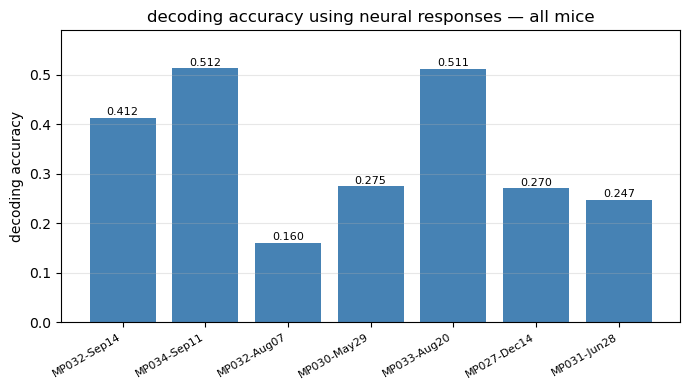

In [5]:
# Decoding accuracy using raw neural responses (1-NN on full neural population)

fig, ax = plt.subplots(figsize=(7, 4))
accs = []

for d, label in zip(datasets, mouse_ids):
    sresp  = preprocess(d)
    nstims = sresp.shape[1]
    cc     = sresp[0] @ sresp[1].T
    cc    /= (sresp[0] ** 2).sum()
    cc    /= (sresp[1] ** 2).sum()
    acc    = (cc.argmax(axis=1) == np.arange(nstims)).mean()
    accs.append(acc)

ax.bar(mouse_ids, accs, color='steelblue')
ax.set_ylabel('decoding accuracy')
ax.set_title('decoding accuracy using neural responses — all mice')
ax.set_xticklabels(mouse_ids, rotation=30, ha='right', fontsize=8)
for i, v in enumerate(accs):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
ax.set_ylim(0, max(accs) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


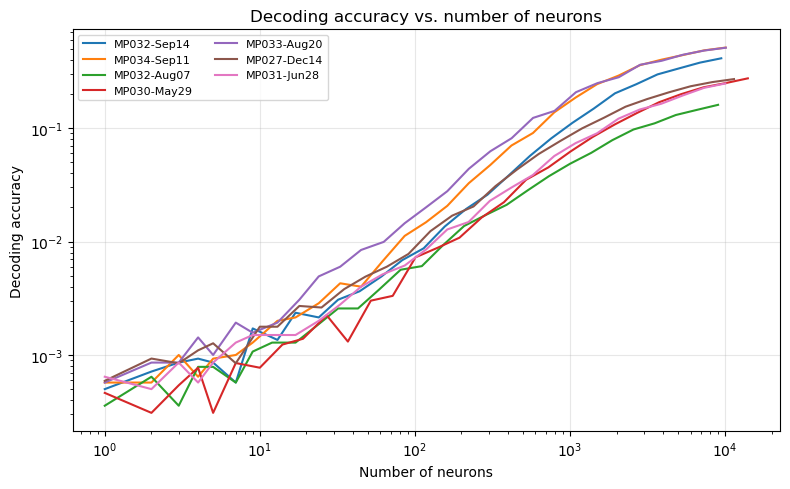

In [6]:
# Decoding accuracy as a function of number of neurons

n_reps = 5
rng = np.random.RandomState(42)

fig, ax = plt.subplots(figsize=(8, 5))

for d, label in zip(datasets, mouse_ids):
    sresp = preprocess(d)
    nstims = sresp.shape[1]
    NN = sresp.shape[2]

    neuron_counts = np.unique(np.round(np.logspace(0, np.log10(NN), 30)).astype(int))
    neuron_counts = neuron_counts[neuron_counts <= NN]

    mean_accs = []
    for n in neuron_counts:
        rep_accs = []
        for _ in range(n_reps):
            idx = rng.choice(NN, size=n, replace=False)
            s0 = sresp[0][:, idx].astype(np.float64)
            s1 = sresp[1][:, idx].astype(np.float64)
            cc = s0 @ s1.T
            cc /= (s0**2).sum()
            cc /= (s1**2).sum()
            acc = (cc.argmax(axis=1) == np.arange(nstims)).mean()
            rep_accs.append(acc)
        mean_accs.append(np.mean(rep_accs))

    ax.plot(neuron_counts, mean_accs, label=label, lw=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of neurons')
ax.set_ylabel('Decoding accuracy')
ax.set_title('Decoding accuracy vs. number of neurons')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


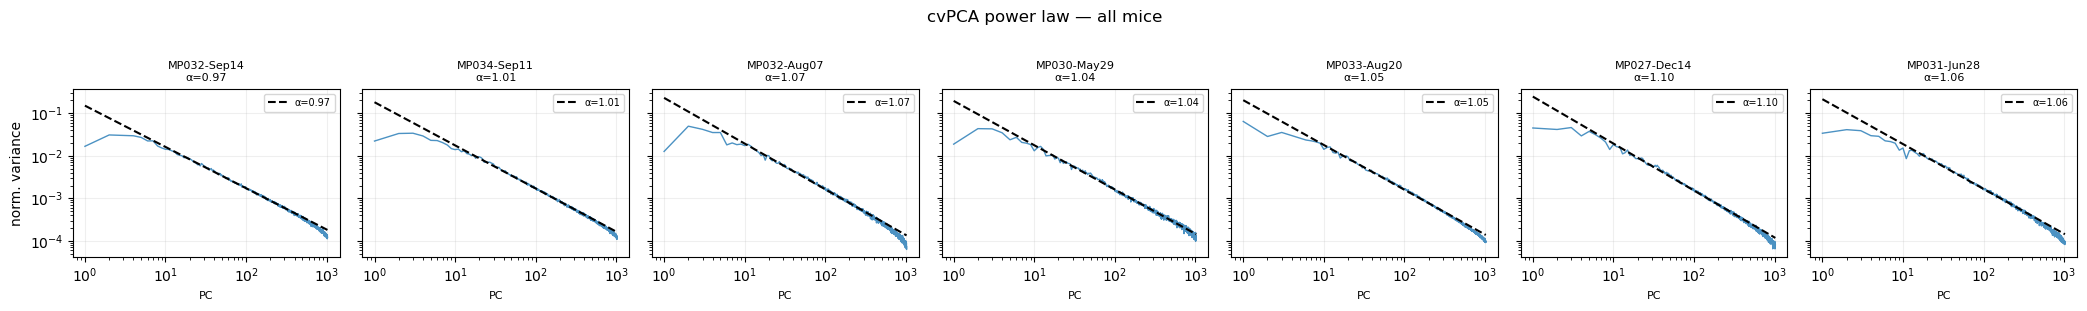

In [6]:

# Power law: cross-validated variance spectrum (cvPCA) fitted with a power law
# Alpha ≈ 1 means variance decays as 1/k — the key finding from Stringer et al.

fig, axes = plt.subplots(1, 7, figsize=(21, 3), sharey=True)

for ax, d, label in zip(axes, datasets, mouse_ids):
    sresp = preprocess(d)

    ss            = shuff_cvPCA(sresp).mean(axis=0)
    ss_norm       = ss / ss.sum()
    alpha, ypred  = get_powerlaw(ss_norm, np.arange(11, 500).astype(int))

    xs = np.arange(1, ss.size + 1)
    ax.loglog(xs, ss_norm, lw=1, alpha=0.8)
    ax.loglog(xs, ypred,   c='k', lw=1.5, linestyle='--', label=f'α={alpha:.2f}')
    ax.set_title(f'{label}\nα={alpha:.2f}', fontsize=8)
    ax.set_xlabel('PC', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

axes[0].set_ylabel('norm. variance')
fig.suptitle('cvPCA power law — all mice', y=1.02)
plt.tight_layout()
plt.show()
